In [74]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
#from Emmanuel_scheme import Temp_prof,met_profiles,w_parcel
#from GB84 import variables_2, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
#from kalman_filter_2 import kalman_filter as kf
from sympy import Symbol, Eq,exp, sqrt, lambdify,Piecewise,Pow,nan
from scipy.optimize import fsolve

In [ ]:
#load the datasets

cabaw_2 = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_multi_radiometer\*.nc')
cabaw_temp = cabaw_2.temperature

In [ ]:
#time to check
time_str = "2024-07-03 12:00:00"

#### Functions


In [ ]:
# calculate specific humidity given the relative humidity
def specific_humidity_from_rh(T, RH, p):
    # T in Kelvin, RH in 0–1, p in Pa
    e_s = 6.112 * np.exp((17.67 * (T - 273.15)) / (T - 29.65)) * 100  # in Pa
    e = RH * e_s
    q = 0.622 * e / (p - 0.378 * e)
    return q

### Data environmental profiles

In [78]:
my_temp = cabaw_temp.sel(time=time_str,method='nearest').values

R=287
g = 9.81
p = np.zeros(cabaw_temp.height.shape[0])
p[0] = 101325
Z = cabaw_temp.height.values
for i in range(1,cabaw_temp.height.shape[0]):

    p[i:] = p[0]/np.exp(g*cabaw_temp.height[i]/R/np.mean(my_temp[0:i+1]))

RH = cabaw_2.relative_humidity.sel(time=time_str,method='nearest').values[0]
T_surf_C = my_temp[0] - 273.15
if RH<1:
    alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH) #from http://dx.doi.org/10.31648/ts.5425
else:

    alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
    
T_d= 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

In [79]:
q_v = specific_humidity_from_rh(my_temp, cabaw_2.relative_humidity.sel(time=time_str,method='nearest').values, p)
T_v_env = my_temp*(1+0.61*q_v)
RH_env = cabaw_2.relative_humidity.sel(time=time_str,method='nearest').values

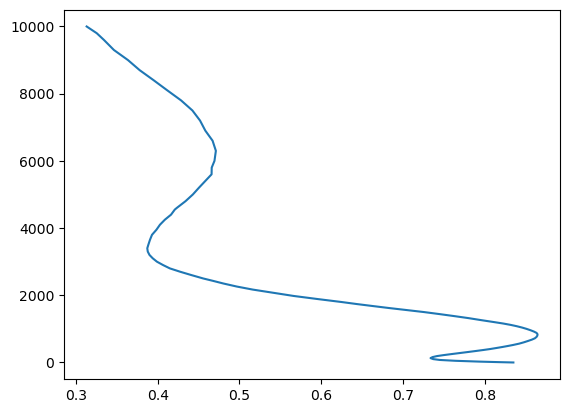

In [80]:
plt.plot(RH_env,Z)

### Parcel Profiles

In [81]:
R_d = 287.05
epsilon = 0.622 
A_1 = 8e-4  # (kg/(m·s²·K^3.5))
A = 2.5e6  # (J/kg)
B = 2.38e3  # (J/(kg K))
cp = 1001
p_n = p[0]  # (kg/(m·s²))
def w(T,P):
    #mixing ratio
    return epsilon*A_1*(T - 223.15)**3.5/P

def L(T):
    #latent heat of condensation
    return A - B*(T - 273.15)

def met_profiles(T_surf,p_surf,p_t):
    p_air = np.linspace(p_surf, p_t, 1000)
    T_air = T_surf*(p_air/p_surf)**0.286
    return p_air, T_air

def e_s(T):
    T_C = T - 273.15  # convert to Celsius

    return np.where(
            T >= 273.15,
            np.exp(34.494 - 4924.99 / (T_C + 237.1)) / (T_C + 105) ** 1.57,
            np.exp(43.494 - 6545.8 / (T_C + 278)) / (T_C + 868) ** 2
        )

def w_sat(T,P):
    e_sat = e_s(T)
    return 0.622*e_s(T)/(P- e_sat)

def e_s_symbolic(T):
    T_C = T - 273.15
    return Piecewise(
        (exp(34.494 - 4924.99 / (T_C + 237.1)) / Pow(T_C + 105, 1.57), T >= 273.15),
        (exp(43.494 - 6545.8 / (T_C + 278)) / Pow(T_C + 868, 2), True)
    )

def w_sat_symbolic(T, P):
    e_sat = e_s_symbolic(T)
    return 0.622 * e_sat / (P - e_sat)

def Temp_prof(T_surf,p_surf,T_d,p_air,T_air):

    p_s = (1/((T_surf - T_d)/223.15 + 1))**3.5 * p_surf
    print(p_s)
    T_s = (1/((T_surf - T_d)/223.15 + 1))* T_surf
    print(T_s)
    theta_moist_parcel = T_s*(p_n/p_s)**0.286*np.exp(L(T_s)*w_sat(T_s,p_s)/(cp*T_s))
    theta_dry = T_surf*(p_n/p_surf)**0.286
    #theta_moist_parcel = T_surf*(1e5/p_surf)**(0.2854*(1-0.28*1e-3*w(T_d,p_surf)))*np.exp((3.376/T_s - 0.00254)*w(T_d,p_surf)*(1+0.81*1e-3*w(T_d,p_surf)))
    print(theta_moist_parcel)
    lcl_index = (np.abs(p_air - p_s)).argmin()


    #print(np.abs(p_air - p_s))
    T_arr = theta_dry*(p_air/p_n)**0.286*np.ones(len(T_air))
    #T_arr[lcl_index] = T_s

    for i in range(lcl_index,len(p_air)):
        #print(i)
        T_parcel = Symbol('T_parcel')
        T_func = Eq(theta_moist_parcel,T_parcel * (p_n / p_air[i])**0.286 * exp((A - B * (T_parcel - 273.15)) * w_sat_symbolic(T_parcel,p_air[i]) / (cp * T_parcel)))
        T_solve = lambdify(T_parcel, T_func.lhs - T_func.rhs, 'numpy')
        T_parcel = fsolve(T_solve, T_arr[i-1])
        T_arr[i] = T_parcel
        #print(T_parcel)

    return T_arr,lcl_index,p_s,T_s


def T_v(T_d,p_surf,p_air,T_arr,lcl_index):

    q_t = w_sat(T_d,p_surf)
    q_v = np.zeros(len(T_arr))
    q_l = np.zeros(len(T_arr))
    q_v[0:lcl_index] = q_t*np.ones(lcl_index)
    q_v[lcl_index:] = w_sat(T_arr[lcl_index:],p_air[lcl_index:])
    q_l[0:lcl_index] = 0
    q_l[lcl_index:] = q_t - q_v[lcl_index:]

    T_v_moist = T_arr*(1 +0.61*q_v - q_l)
    print(q_t)
    return T_v_moist,q_v


In [82]:
temp_parcel,lcl_index,p_s_value,T_s_value = Temp_prof(my_temp[0],p[0],T_d,p,my_temp)
Z_lcl = R*np.mean(temp_parcel[0:lcl_index+1])*np.log(p[lcl_index+1]/p[0])


if abs(p[lcl_index] - p_s_value)<0.1:
         lcl_height = cabaw_2.height[lcl_index]

elif (p[lcl_index] - p_s_value)>0:
        temp_parcel = np.insert(temp_parcel,lcl_index+1,T_s_value)
        p = np.insert(p,lcl_index+1,p_s_value)
        Z_lcl = R*np.mean(temp_parcel[0:lcl_index+2])*np.log(p[0]/p[lcl_index+1])/g
        Z = np.insert(Z,lcl_index+1,Z_lcl)
        lcl_index = np.argwhere(Z == Z_lcl).item()

        if my_temp[lcl_index+1]>my_temp[lcl_index]:
                my_temp_lcl = my_temp[lcl_index] + (my_temp[lcl_index+1]-my_temp[lcl_index])/(p[lcl_index]-p[lcl_index+1])*((p[lcl_index]-p_s_value))
        else:
                my_temp_lcl = my_temp[lcl_index+1] + (my_temp[lcl_index]-my_temp[lcl_index+1])/(p[lcl_index]-p[lcl_index+1])*((p[lcl_index]-p_s_value))
        #my_temp = np.insert(my_temp,lcl_index+1,my_temp_lcl.item())
        
        if RH_env[lcl_index+1]>RH_env[lcl_index]:
                RH_lcl = RH_env[lcl_index] + (RH_env[lcl_index+1]-RH_env[lcl_index])/(p[lcl_index]-p[lcl_index+1])*((p[lcl_index]-p_s_value))
        else:
                RH_lcl = RH_env[lcl_index+1] + (RH_env[lcl_index]-RH_env[lcl_index+1])/(p[lcl_index]-p[lcl_index+1])*((p[lcl_index]-p_s_value))
        my_temp = np.insert(my_temp,lcl_index,my_temp_lcl.item())
        qv_lcl = specific_humidity_from_rh(my_temp[lcl_index], RH_lcl, p_s_value)
        q_v = np.insert(q_v,lcl_index,qv_lcl.item())

else:
        temp_parcel = np.insert(temp_parcel,lcl_index,T_s_value)
        p = np.insert(p,lcl_index,p_s_value)
        Z_lcl = R*np.mean(temp_parcel[0:lcl_index+1])*np.log(p[0]/p[lcl_index])/g
        Z = np.insert(Z,lcl_index,Z_lcl)

        if my_temp[lcl_index+1]>my_temp[lcl_index]:
                my_temp_lcl = my_temp[lcl_index] + (my_temp[lcl_index+1]-my_temp[lcl_index])/(p[lcl_index]-p[lcl_index+1])*((-p[lcl_index]+p_s_value))
        else:
                my_temp_lcl = my_temp[lcl_index+1] + (my_temp[lcl_index]-my_temp[lcl_index+1])/(p[lcl_index]-p[lcl_index+1])*((-p[lcl_index]+p_s_value))
        if RH_env[lcl_index+1]>RH_env[lcl_index]:
                RH_lcl = RH_env[lcl_index] + (RH_env[lcl_index+1]-RH_env[lcl_index])/(p[lcl_index]-p[lcl_index+1])*((-p[lcl_index]+p_s_value))
        else:
                RH_lcl = RH_env[lcl_index+1] + (RH_env[lcl_index]-RH_env[lcl_index+1])/(p[lcl_index]-p[lcl_index+1])*((-p[lcl_index]+p_s_value))
        my_temp = np.insert(my_temp,lcl_index,my_temp_lcl.item())
        qv_lcl = specific_humidity_from_rh(my_temp[lcl_index], RH_lcl, p_s_value)
        q_v = np.insert(q_v,lcl_index,qv_lcl.item())




97120.23912600536
282.20706070061897
304.99987720021693


In [83]:
lcl_index

14

In [84]:
p[lcl_index] - p_s_value

0.0

14

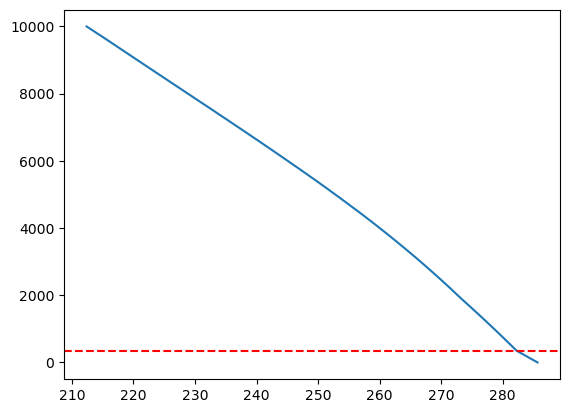

In [85]:
plt.plot(temp_parcel,Z)
#plt.plot(my_temp,cabaw_2.height)
plt.axhline(y=Z_lcl,color='r',linestyle='--')
lcl_index

In [86]:
T_v_parcel,q_v_parcel = T_v(T_d,p[0],p,temp_parcel,lcl_index)
T_v_env = my_temp*(1+0.61*q_v)

0.007517052236839603


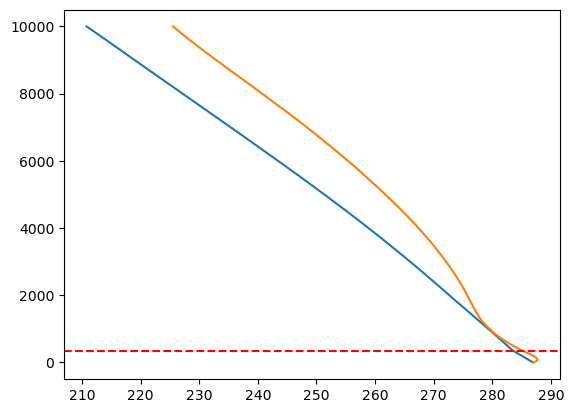

In [87]:
plt.plot(T_v_parcel,Z)
plt.plot(T_v_env,Z)
plt.axhline(y=Z_lcl,color='r',linestyle='--')

In [88]:
def find_lfc(T_v_parcel,T_v_env,Z,lcl_index):
    if T_v_parcel[lcl_index] > T_v_env[lcl_index]:
        return lcl_index,lcl_index
    else:
        condition = T_v_parcel[lcl_index:]>T_v_env[lcl_index:]
        if np.any(condition):
            LFC_index = np.argmax(condition) + lcl_index
            #find the energy in the boundary layer
            BIN_lower = np.argmax(T_v_parcel>T_v_env)
            BIN_upper = np.argmax(T_v_parcel[BIN_lower:]<T_v_env[BIN_lower:]) + BIN_lower
            BIN = 0.0

            y_bin = g * (T_v_parcel[BIN_lower:BIN_upper] - T_v_env[BIN_lower:BIN_upper]) / T_v_parcel[BIN_lower:BIN_upper]
            BIN = np.trapz(y_bin, Z[BIN_lower:BIN_upper])
        
            #find how much energy needed to go above the CIN
            CIN = 0.0
            y_cin = g * (T_v_parcel[BIN_lower:BIN_upper] - T_v_env[BIN_lower:BIN_upper]) / T_v_parcel[BIN_lower:BIN_upper]
            CIN = abs(np.trapz(y_cin, Z[BIN_lower:BIN_upper]))

            if CIN <= BIN:
                 return lcl_index,LFC_index
            else:
                return 'not reached'
        
        else:
            return 'no LFC'



def cloud_top(lcl_index,LFC_index,Z,Z_b,T_t,p,p_t):
    condition = T_v_parcel[lcl_index:]<T_v_env[lcl_index:]
    if LFC_index == lcl_index:
        if np.any(condition):
            top_index = np.argmax(condition) + lcl_index
            Z_t = Z[top_index-1] + (Z[top_index] - Z[top_index-1])/((T_v_parcel-T_v_env)[top_index-1] - (T_v_parcel-T_v_env)[top_index])*\
                                     ((T_v_parcel-T_v_env)[top_index-1])
        else:
            index_p_t = np.argmin(p_t>p)
            T_high = np.insert(temp_parcel,index_p_t,T_t)
            Z_t = R*np.mean(T_high)*np.log(p[0]/p_t)/g

         
    else:
            Z_t = 0 

    return max(0,Z_t - Z_b), Z_t


In [89]:
Z_c,Z_t = cloud_top(lcl_index,find_lfc(T_v_parcel,T_v_env,Z,lcl_index),Z,Z_lcl,220,p,40000)

In [ ]:
def calc_p_t(p,lcl_index,Z_t,temp_parcel):
    p_t = p[0]*np.exp(Z_t*g/R*np.mean(temp_parcel[0:lcl_index+1]))
    return p_t

In [91]:
Z_c

0